# Step 2 — Elo ratings from scratch

**Goal:** give every national team a single strength number that goes up when they win and down when they lose, then turn rating differences into win/draw/loss probabilities.

**How Elo works:**
1. Every team starts at **1500**.
2. Before each match, the rating gap gives an **expected score** for the home team:
   `expected = 1 / (1 + 10^(−gap / 400))`, where a win counts 1, a draw 0.5, a loss 0.
3. After the match, both teams move by `K × (actual − expected)`. An upset moves ratings a lot; an expected result barely moves them.

We add three football-specific ideas (from the well-known World Football Elo system):
- **Home advantage:** the home team gets bonus points in the gap calculation.
- **Match importance:** a World Cup game counts more (bigger K) than a friendly.
- **Margin of victory:** winning 4–0 moves ratings more than winning 1–0.

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# Save everything in Google Drive, so each notebook can use the previous notebook's outputs.
# Colab will ask for permission to access your Drive the first time.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/world-cup-prediction"
except ImportError:          # running on your own computer instead of Colab
    BASE = "."
os.makedirs(BASE, exist_ok=True)
os.chdir(BASE)
for folder in ["data", "models", "preds"]:
    os.makedirs(folder, exist_ok=True)
print("Working folder:", os.getcwd())

Mounted at /content/drive
Working folder: /content/drive/MyDrive/world-cup-prediction


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
START_YEAR = 1990

def load_matches():
    """Load cleaned matches (downloading and cleaning them first if needed)."""
    path = "data/matches_clean.csv"
    if not os.path.exists(path):
        raw = pd.read_csv(URL, parse_dates=["date"])
        df = raw.dropna(subset=["home_score", "away_score"])
        df = df[df["date"].dt.year >= START_YEAR].copy()
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values(["date", "home_team", "away_team"], kind="stable").reset_index(drop=True)
    df["match_id"] = df.index
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["neutral"] = df["neutral"].astype(bool)
    # Result coded as a class: 0 = home win, 1 = draw, 2 = away win
    df["result"] = np.select([df["home_score"] > df["away_score"],
                              df["home_score"] < df["away_score"]], [0, 2], default=1)
    return df

def add_splits(df):
    """train: before 2024 | val: 2024 until the World Cup | test: the 2026 World Cup matches."""
    wc26 = (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2026)
    test_start = df.loc[wc26, "date"].min() if wc26.any() else pd.Timestamp("2026-06-11")
    val_start = pd.Timestamp("2024-01-01")
    df["split"] = np.select([df["date"] < val_start, df["date"] < test_start, wc26],
                            ["train", "val", "test"], default="after")
    return df, val_start, test_start

matches, VAL_START, TEST_START = add_splits(load_matches())
print(matches["split"].value_counts().to_string())
print("Validation starts:", VAL_START.date(), "| Test (World Cup 2026) starts:", TEST_START.date())

split
train    29787
val       2564
after      366
test       104
Validation starts: 2024-01-01 | Test (World Cup 2026) starts: 2026-06-11


## Train / validation / test split

To judge the models honestly, they must be tested on matches they have **never seen**:

| Split | Matches | Used for |
| --- | --- | --- |
| **train** | before 2024 | fitting the models |
| **val** | 2024 → start of World Cup 2026 | comparing models and tuning settings |
| **test** | the 2026 World Cup itself | the final, one-time exam |

Splitting by **time** (not randomly) matters in sport: a model must never learn from the future.

## 2. The Elo rules

In [3]:
START_RATING = 1500

MAJOR_TOURNAMENTS = {"UEFA Euro", "Copa América", "African Cup of Nations", "AFC Asian Cup",
                     "Gold Cup", "CONCACAF Championship", "Confederations Cup",
                     "UEFA Nations League", "CONCACAF Nations League", "OFC Nations Cup"}

def k_factor(tournament):
    """How much a match can move the ratings, by importance."""
    if tournament == "FIFA World Cup":
        return 60
    if "qualification" in tournament.lower():
        return 40
    if tournament in MAJOR_TOURNAMENTS:
        return 50
    if tournament == "Friendly":
        return 20
    return 30

def margin_multiplier(goal_diff):
    """Bigger wins move ratings more."""
    gd = abs(goal_diff)
    if gd <= 1:
        return 1.0
    if gd == 2:
        return 1.5
    return (11 + gd) / 8

def run_elo(df, home_adv):
    """Go through matches in date order. Returns each team's rating BEFORE every match
    (so there's no peeking at the result) plus the final ratings."""
    ratings = {}
    home_pre, away_pre = [], []
    for r in df.itertuples(index=False):
        h = ratings.get(r.home_team, START_RATING)
        a = ratings.get(r.away_team, START_RATING)
        home_pre.append(h)
        away_pre.append(a)

        gap = h - a + (0 if r.neutral else home_adv)
        expected = 1 / (1 + 10 ** (-gap / 400))
        actual = 1.0 if r.home_score > r.away_score else 0.5 if r.home_score == r.away_score else 0.0

        change = k_factor(r.tournament) * margin_multiplier(r.home_score - r.away_score) * (actual - expected)
        ratings[r.home_team] = h + change
        ratings[r.away_team] = a - change
    return np.array(home_pre), np.array(away_pre), ratings

## 3. From rating gap to win / draw / loss probabilities

Elo gives one expected score, but we need **three** probabilities. We learn the mapping from data with a **multinomial logistic regression**: input = rating gap, output = P(home win), P(draw), P(away win).

We skip the first few years (before 1994) when training it, because every team started at 1500 in 1990 and the ratings needed time to settle. This is called a **burn-in** period.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

def elo_X(gap):
    """Feature used by the probability model: the rating gap in hundreds of points."""
    return (np.asarray(gap, dtype=float) / 100).reshape(-1, 1)

def fit_and_score(home_adv):
    home_pre, away_pre, _ = run_elo(matches, home_adv)
    gap = home_pre - away_pre + np.where(matches["neutral"], 0, home_adv)
    train = (matches["split"] == "train") & (matches["date"].dt.year >= 1994)
    val = matches["split"] == "val"
    model = LogisticRegression(max_iter=1000).fit(elo_X(gap[train]), matches.loc[train, "result"])
    val_loss = log_loss(matches.loc[val, "result"], model.predict_proba(elo_X(gap[val])), labels=[0, 1, 2])
    return val_loss, model, home_pre, away_pre, gap

## 4. Tune the home advantage on the validation set

How many Elo points is playing at home worth? Instead of guessing, we try a few values and keep the one with the lowest **log loss** on the validation matches.

**Log loss** measures how good probabilities are: it heavily punishes being confidently wrong. Lower is better. Guessing ⅓ for each outcome gives about 1.099.

In [5]:
results = {}
for ha in [0, 50, 75, 100, 125, 150]:
    results[ha] = fit_and_score(ha)[0]
    print(f"home advantage {ha:>3}: validation log loss = {results[ha]:.4f}")

HOME_ADV = min(results, key=results.get)
print("\nBest home advantage:", HOME_ADV, "Elo points")

home advantage   0: validation log loss = 0.8733
home advantage  50: validation log loss = 0.8697
home advantage  75: validation log loss = 0.8693
home advantage 100: validation log loss = 0.8700
home advantage 125: validation log loss = 0.8714
home advantage 150: validation log loss = 0.8734

Best home advantage: 75 Elo points


In [6]:
val_loss, elo_model, home_pre, away_pre, gap = fit_and_score(HOME_ADV)
matches["home_elo"], matches["away_elo"], matches["elo_diff"] = home_pre, away_pre, gap

# Baseline: always predict the training-set frequency of each result
base_rates = matches.loc[matches["split"] == "train", "result"].value_counts(normalize=True).sort_index().values
val = matches["split"] == "val"
base_loss = log_loss(matches.loc[val, "result"], np.tile(base_rates, (val.sum(), 1)), labels=[0, 1, 2])
print(f"Validation log loss — base rates: {base_loss:.4f} | Elo: {val_loss:.4f}")

Validation log loss — base rates: 1.0541 | Elo: 0.8693


### What the probability model learned

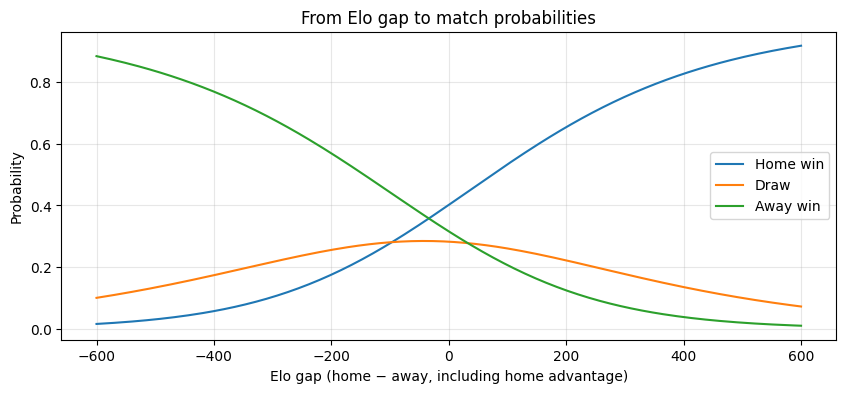

In [7]:
gaps = np.linspace(-600, 600, 200)
probs = elo_model.predict_proba(elo_X(gaps))
for i, label in enumerate(["Home win", "Draw", "Away win"]):
    plt.plot(gaps, probs[:, i], label=label)
plt.xlabel("Elo gap (home − away, including home advantage)")
plt.ylabel("Probability")
plt.title("From Elo gap to match probabilities")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Notice the draw curve peaks when the teams are evenly matched and shrinks as the gap grows. That's exactly how football behaves.

## 5. Ratings just before the 2026 World Cup

For the tournament simulation we need each team's rating **as it stood on the opening day**, using only earlier matches.

In [8]:
_, _, ratings_wc = run_elo(matches[matches["date"] < TEST_START], HOME_ADV)
elo_wc = (pd.Series(ratings_wc, name="elo").rename_axis("team")
            .sort_values(ascending=False).reset_index())
elo_wc.head(20)

,team,elo
0,Spain,2193.406241
1,Argentina,2167.411071
2,France,2099.126739
3,England,2067.135831
4,Brazil,2046.965121
5,Colombia,2043.988439
6,Portugal,2030.757981
7,Ecuador,2008.697850
8,Japan,1990.142067
9,Netherlands,1985.890466


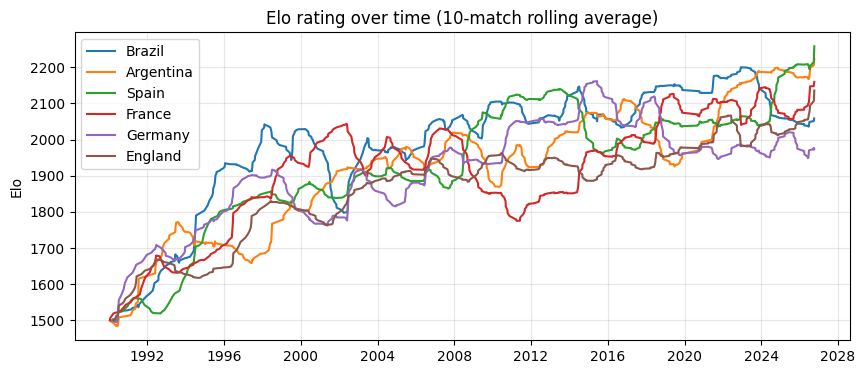

In [9]:
# Rating history for some big teams
long = pd.concat([
    pd.DataFrame({"date": matches["date"], "team": matches["home_team"], "elo": matches["home_elo"]}),
    pd.DataFrame({"date": matches["date"], "team": matches["away_team"], "elo": matches["away_elo"]})])
teams_to_plot = [t for t in ["Brazil", "Argentina", "Spain", "France", "Germany", "England"]
                 if t in set(long["team"])]
for team in teams_to_plot:
    t = long[long["team"] == team].sort_values("date")
    plt.plot(t["date"], t["elo"].rolling(10, min_periods=1).mean(), label=team)
plt.title("Elo rating over time (10-match rolling average)")
plt.ylabel("Elo"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Save outputs for the next notebooks

In [10]:
import joblib

matches[["match_id", "home_elo", "away_elo", "elo_diff"]].to_csv("data/elo_features.csv", index=False)
elo_wc.to_csv("models/elo_ratings_wc2026.csv", index=False)
joblib.dump(elo_model, "models/elo_wdl.joblib")
json.dump({"home_adv": HOME_ADV}, open("models/elo_config.json", "w"))

evaluate = matches["split"].isin(["val", "test"])
p = elo_model.predict_proba(elo_X(matches.loc[evaluate, "elo_diff"]))
pd.DataFrame({"match_id": matches.loc[evaluate, "match_id"],
              "p_home": p[:, 0], "p_draw": p[:, 1], "p_away": p[:, 2]}).to_csv("preds/elo_preds.csv", index=False)
print("Saved Elo features, ratings, model and predictions.")

Saved Elo features, ratings, model and predictions.
